# Qual dataset é mais fácil para modelos de linguagem?

Este experimento apresenta as mesmas questões a dois modelos generativos e mede a acurácia em cada geração:

1. `microsoft/Phi-4-mini-instruct` (Phi-4 mini), executado primeiro;
2. `meta-llama/Llama-3.1-8B-Instruct` (Llama 3.1 8B, correspondente ao `llama3.1:8b` do Ollama), executado depois.

Os datasets avaliados são `instruction-only` e `context-grounded`. As respostas brutas são salvas em `pipeline/mcq_output/avaliacao_facilidade/`, permitindo retomar a análise sem repetir a inferência.

## Interpretação

O dataset mais fácil para um modelo é aquele em que ele obtém maior acurácia, idealmente com desempenho consistente entre assuntos e níveis de dificuldade. A comparação entre dois modelos reduz o risco de concluir que um dataset é fácil apenas por causa de uma particularidade de um único modelo.

In [1]:
import os 
os.environ['CUDA_VISIBLE_DEVICES'] = '7'

In [2]:
import gc
import json
import re
import sys
from pathlib import Path

# Remove um matplotlib parcialmente importado por uma execução interrompida do kernel.
for module_name in list(sys.modules):
    if module_name == "matplotlib" or module_name.startswith("matplotlib."):
        del sys.modules[module_name]

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

ROOT = Path("/home/rodrigo.flexa/MCQ_CONTEXT_GEN")
DATA_DIR = ROOT / "pipeline/mcq_output"
RESULT_DIR = DATA_DIR / "avaliacao_facilidade"
RESULT_DIR.mkdir(parents=True, exist_ok=True)

DATASETS = {
    "instruction-only": DATA_DIR / "dataset_mcq_instrucao.jsonl",
    "context-grounded": DATA_DIR / "dataset_mcq_petroles.jsonl",
}
MODEL_PHI = "microsoft/Phi-4-mini-instruct"
MODEL_LLAMA = "meta-llama/Llama-3.1-8B-Instruct"

print("Dispositivo:", "cuda" if torch.cuda.is_available() else "cpu")
for name, path in DATASETS.items():
    print(name, "->", sum(1 for _ in open(path, encoding="utf-8")), "questões")

Dispositivo: cuda
instruction-only -> 50 questões
context-grounded -> 51 questões


In [3]:
import unicodedata

ALT_LETTERS = {"A", "B", "C", "D"}
DIFF_MAP = {"facil": "facil", "media": "media", "dificil": "dificil"}


def strip_accents(text):
    return "".join(c for c in unicodedata.normalize("NFD", str(text)) if unicodedata.category(c) != "Mn")


def norm_diff(text):
    if not text:
        return None
    return DIFF_MAP.get(strip_accents(text).strip().lower().rstrip("."))


def iter_docx_blocks(doc):
    import docx
    from docx.oxml.ns import qn
    for child in doc.element.body.iterchildren():
        if child.tag == qn("w:p"):
            yield "p", docx.text.paragraph.Paragraph(child, doc)
        elif child.tag == qn("w:tbl"):
            yield "t", docx.table.Table(child, doc)


def classify_table(table):
    rows = [[cell.text.strip() for cell in row.cells] for row in table.rows]
    first = [row[0] if row else "" for row in rows]
    joined = " ".join(" ".join(row) for row in rows)
    if any(re.search(r"quest[aã]o\s*\d+", cell, re.IGNORECASE) for cell in first):
        return "header", rows
    if "Aprovar" in joined and "Descartar" in joined:
        return "ignore", rows
    if len(rows) == 4 and all(row and row[0].upper() in ALT_LETTERS for row in rows):
        return "alternatives", rows
    keys = [strip_accents(cell.lower()).rstrip(":") for cell in first]
    if any(key in ("gabarito", "resposta correta") for key in keys):
        return "metadata", rows
    if len(rows) == 1 and len(rows[0]) >= 4 and strip_accents(rows[0][0].lower()) == "dificuldade" and strip_accents(rows[0][2].lower()) == "tema":
        return "difficulty_topic", rows
    return "ignore", rows


def parse_mazzuco_docx(path):
    import docx
    doc = docx.Document(str(path))
    questions = []
    stem, alternatives, metadata = [], {}, {}
    active = False
    metadata_done = False

    def flush():
        if not active:
            return
        text = " ".join(part for part in stem if part).strip()
        alts = [alternatives.get(letter, "") for letter in "ABCD"]
        answer = str(metadata.get("gabarito", "")).strip().upper()
        if text and all(alts) and answer in ALT_LETTERS:
            questions.append({"stem": text, "alternatives": alts, "correct_answer_index": "ABCD".index(answer), "difficulty": norm_diff(metadata.get("dificuldade"))})

    for kind, item in iter_docx_blocks(doc):
        if kind == "p":
            text = item.text.strip()
            if not text:
                continue
            if re.match(r"^quest[aã]o\s*\d+\b", text, re.IGNORECASE):
                flush()
                stem, alternatives, metadata = [], {}, {}
                active, metadata_done = True, False
                continue
            if "CURADORIA" in text.upper() or re.match(r"^(alternativas?|notas de curadoria)", text, re.IGNORECASE):
                continue
            match = re.match(r"^([A-D])[.)]\s*(.+)$", text)
            if match:
                alternatives[match.group(1)] = match.group(2).strip()
            elif not alternatives:
                stem.append(re.sub(r"^(enunciado|subtema)\s*:\s*", "", text, flags=re.IGNORECASE))
        else:
            table_type, rows = classify_table(item)
            if table_type == "header":
                flush()
                stem, alternatives, metadata = [], {}, {}
                active, metadata_done = True, False
                for row in rows:
                    for cell in row:
                        if norm_diff(cell):
                            metadata["dificuldade"] = norm_diff(cell)
            elif table_type == "difficulty_topic":
                metadata["dificuldade"] = norm_diff(rows[0][1])
            elif table_type == "alternatives":
                for row in rows:
                    alternatives[row[0].upper()] = row[1].strip()
            elif table_type == "metadata" and not metadata_done:
                metadata_done = True
                for row in rows:
                    key, value = (row[0], row[1]) if len(row) >= 2 else ((row[0].split(":", 1) + [""])[:2])
                    key = strip_accents(key.lower()).rstrip(":").strip()
                    if key in ("gabarito", "resposta correta"):
                        metadata["gabarito"] = value.strip()
                    elif key in ("dificuldade", "grau de dificuldade"):
                        metadata["dificuldade"] = norm_diff(value)
    flush()
    return questions


def load_questions():
    rows = []
    for dataset_name, path in DATASETS.items():
        for question_id, line in enumerate(open(path, encoding="utf-8")):
            item = json.loads(line)
            item.update(dataset=dataset_name, question_id=question_id)
            rows.append(item)
    for path in sorted((ROOT / "archive/questions_mazzuco").glob("*.docx")):
        for question_id, item in enumerate(parse_mazzuco_docx(path)):
            item.update(dataset="mazzuco (GPT Plus)", question_id=question_id)
            rows.append(item)
    return pd.DataFrame(rows)


def format_prompt(row):
    alternatives = "\n".join(f"{letter}) {text}" for letter, text in zip("ABCD", row["alternatives"]))
    return ("Você está respondendo uma questão técnica de múltipla escolha em português.\n"
            "Escolha a alternativa correta. Não explique.\n"
            "Responda somente com uma letra: A, B, C ou D.\n\n"
            f"Enunciado: {row['stem']}\n\nAlternativas:\n{alternatives}\n\nResposta:")


def extract_answer(text):
    match = re.search(r"\b([ABCD])\b", str(text).strip().upper())
    return match.group(1) if match else None


questions = load_questions()
questions["prompt"] = questions.apply(format_prompt, axis=1)
questions["gold_letter"] = questions["correct_answer_index"].map(lambda index: "ABCD"[int(index)])
print(questions["dataset"].value_counts())
questions[["dataset", "question_id", "difficulty", "gold_letter"]].head()

dataset
mazzuco (GPT Plus)    120
context-grounded       51
instruction-only       50
Name: count, dtype: int64


,dataset,question_id,difficulty,gold_letter
0,instruction-only,0,facil,A
1,instruction-only,1,dificil,B
2,instruction-only,2,media,C
3,instruction-only,3,media,D
4,instruction-only,4,facil,A


In [4]:
def parse_produtos_quimicos(path):
    import docx
    from docx.oxml.ns import qn

    doc = docx.Document(str(path))
    blocks = []
    for child in doc.element.body.iterchildren():
        if child.tag == qn("w:p"):
            blocks.append(("p", docx.text.paragraph.Paragraph(child, doc).text.strip()))
        elif child.tag == qn("w:tbl"):
            table = docx.table.Table(child, doc)
            blocks.append(("t", [[cell.text.strip() for cell in row.cells] for row in table.rows]))

    parsed = []
    current = None

    def flush():
        if current and current["stem"] and len(current["alternatives"]) == 4 and current["gold"] in "ABCD":
            parsed.append({
                "stem": current["stem"],
                "alternatives": current["alternatives"],
                "correct_answer_index": "ABCD".index(current["gold"]),
                "difficulty": current["difficulty"],
            })

    for kind, value in blocks:
        if kind == "p":
            if re.match(r"^Quest[aã]o\s*\d+", value, re.IGNORECASE):
                flush()
                current = {"stem": "", "alternatives": [], "gold": "", "difficulty": None}
                continue
            if current is None or not value or value.startswith("Notas de curadoria"):
                continue
            match = re.match(r"^([A-D])[.)]\s*(.+)$", value)
            if match:
                current["alternatives"].append(match.group(2).strip())
            elif not current["alternatives"] and not value.lower().startswith("alternativas"):
                current["stem"] += (" " if current["stem"] else "") + re.sub(r"^Enunciado:\s*", "", value, flags=re.IGNORECASE)
        elif current is not None:
            cells = [cell for row in value for cell in row]
            joined = " ".join(cells)
            answer = re.search(r"Gabarito\s*:\s*([ABCD])\b", joined, re.IGNORECASE)
            if answer:
                current["gold"] = answer.group(1).upper()
            difficulty = re.search(r"Dificuldade\s*\|\s*(facil|media|dificil)", joined, re.IGNORECASE)
            if difficulty:
                current["difficulty"] = difficulty.group(1).lower()
    flush()
    return parsed


product_file = ROOT / "archive/questions_mazzuco/Questoes_Produtos_Quimicos_FPSO_40.docx"
product_rows = parse_produtos_quimicos(product_file)
for question_id, item in enumerate(product_rows):
    item.update(dataset="mazzuco (GPT Plus)", question_id=question_id + 40)
questions = pd.concat([questions, pd.DataFrame(product_rows)], ignore_index=True)
questions["prompt"] = questions.apply(format_prompt, axis=1)
questions["gold_letter"] = questions["correct_answer_index"].map(lambda index: "ABCD"[int(index)])
print("Questões adicionadas do arquivo Produtos Químicos:", len(product_rows))
print(questions["dataset"].value_counts())
assert len(questions) == 261, f"Esperadas 261 questões, obtidas {len(questions)}"

Questões adicionadas do arquivo Produtos Químicos: 40
dataset
mazzuco (GPT Plus)    160
context-grounded       51
instruction-only       50
Name: count, dtype: int64


## 1. Phi-4 mini

O Phi-4 mini é executado antes do segundo modelo. A célula salva cada resposta imediatamente em JSONL; se já houver um arquivo completo, ele é reutilizado.

In [5]:
def load_model(model_name):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    dtype = torch.bfloat16 if torch.cuda.is_available() else torch.float32
    model = AutoModelForCausalLM.from_pretrained(
        model_name, torch_dtype=dtype, device_map="auto" if torch.cuda.is_available() else None
    )
    if not torch.cuda.is_available():
        model.to("cpu")
    model.eval()
    return tokenizer, model


def generate_one(row, tokenizer, model):
    messages = [
        {"role": "system", "content": "Responda somente com A, B, C ou D."},
        {"role": "user", "content": row["prompt"]},
    ]
    inputs = tokenizer.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_tensors="pt",
        return_dict=True,
    )
    device = next(model.parameters()).device
    inputs = {name: value.to(device) for name, value in inputs.items()}
    input_length = inputs["input_ids"].shape[-1]
    with torch.inference_mode():
        output = model.generate(
            **inputs,
            max_new_tokens=8,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )
    generated = output[0, input_length:]
    raw = tokenizer.decode(generated, skip_special_tokens=True).strip()
    return raw, extract_answer(raw)


def run_model(model_name, model_label, questions):
    output_path = RESULT_DIR / f"{model_label}.jsonl"
    if output_path.exists() and sum(1 for _ in open(output_path, encoding="utf-8")) == len(questions):
        print("Resultados já existentes; reutilizando", output_path)
        return pd.DataFrame([json.loads(line) for line in open(output_path, encoding="utf-8")])

    tokenizer, model = load_model(model_name)
    results = []
    with open(output_path, "w", encoding="utf-8") as handle:
        for position, (_, row) in enumerate(questions.iterrows(), start=1):
            raw, predicted = generate_one(row, tokenizer, model)
            result = {
                "dataset": row["dataset"], "question_id": int(row["question_id"]),
                "difficulty": row["difficulty"], "gold_letter": row["gold_letter"],
                "predicted_letter": predicted, "raw_response": raw,
                "correct": predicted == row["gold_letter"],
            }
            results.append(result)
            handle.write(json.dumps(result, ensure_ascii=False) + "\n")
            handle.flush()
            if position % 10 == 0 or position == len(questions):
                print(f"{model_label}: {position}/{len(questions)}")
    del model, tokenizer
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return pd.DataFrame(results)

phi_results = run_model(MODEL_PHI, "phi4_mini", questions)
phi_results.head()

Resultados já existentes; reutilizando /home/rodrigo.flexa/MCQ_CONTEXT_GEN/pipeline/mcq_output/avaliacao_facilidade/phi4_mini.jsonl


,dataset,question_id,difficulty,gold_letter,predicted_letter,raw_response,correct
0,instruction-only,0,facil,A,A,A) Investigar gargalos nos processos,True
1,instruction-only,1,dificil,B,B,B) Avaliar o custo total de,True
2,instruction-only,2,media,C,C,C) Ajustar os parâmetros operacionais,True
3,instruction-only,3,media,D,D,D) Reforçar o treinamento e,True
4,instruction-only,4,facil,A,A,A) O custo da remoção versus,True


,dataset,n,accuracy,accuracy_pct,model
0,context-grounded,51,0.784314,78.431373,Phi-4 mini
1,instruction-only,50,0.880000,88.000000,Phi-4 mini
2,mazzuco (GPT Plus),160,0.987500,98.750000,Phi-4 mini


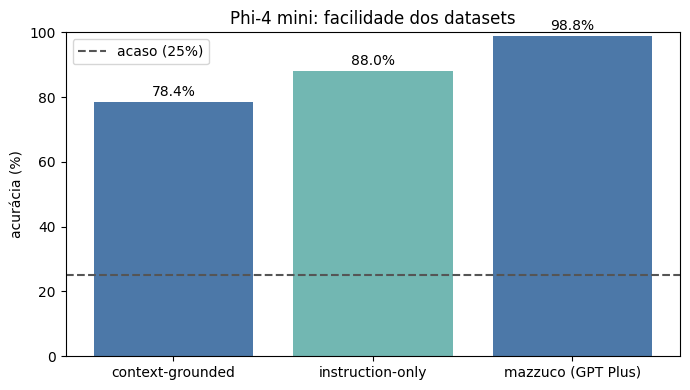

In [6]:
def summarize(results, model_label):
    summary = results.groupby("dataset", as_index=False).agg(
        n=("correct", "size"), accuracy=("correct", "mean")
    )
    summary["accuracy_pct"] = 100 * summary["accuracy"]
    summary["model"] = model_label
    return summary

phi_summary = summarize(phi_results, "Phi-4 mini")
display(phi_summary)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(phi_summary["dataset"], phi_summary["accuracy_pct"], color=["#4c78a8", "#72b7b2"])
ax.axhline(25, color="#555555", linestyle="--", label="acaso (25%)")
ax.set_ylim(0, 100)
ax.set_ylabel("acurácia (%)")
ax.set_title("Phi-4 mini: facilidade dos datasets")
for bar, value in zip(bars, phi_summary["accuracy_pct"]):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 2, f"{value:.1f}%", ha="center")
ax.legend()
plt.tight_layout(); plt.show()

## 2. Llama 3.1 8B

O segundo modelo é executado somente depois da finalização e do gráfico do Phi-4 mini. A memória do primeiro modelo é liberada antes do carregamento do Llama.

In [7]:
llama_results = run_model(MODEL_LLAMA, "llama31_8b", questions)
llama_results.head()

Resultados já existentes; reutilizando /home/rodrigo.flexa/MCQ_CONTEXT_GEN/pipeline/mcq_output/avaliacao_facilidade/llama31_8b.jsonl


,dataset,question_id,difficulty,gold_letter,predicted_letter,raw_response,correct
0,instruction-only,0,facil,A,A,A,True
1,instruction-only,1,dificil,B,B,B,True
2,instruction-only,2,media,C,C,C,True
3,instruction-only,3,media,D,D,D,True
4,instruction-only,4,facil,A,A,A,True


,dataset,n,accuracy,accuracy_pct,model
0,context-grounded,51,0.784314,78.431373,Llama 3.1 8B
1,instruction-only,50,0.960000,96.000000,Llama 3.1 8B
2,mazzuco (GPT Plus),160,0.987500,98.750000,Llama 3.1 8B


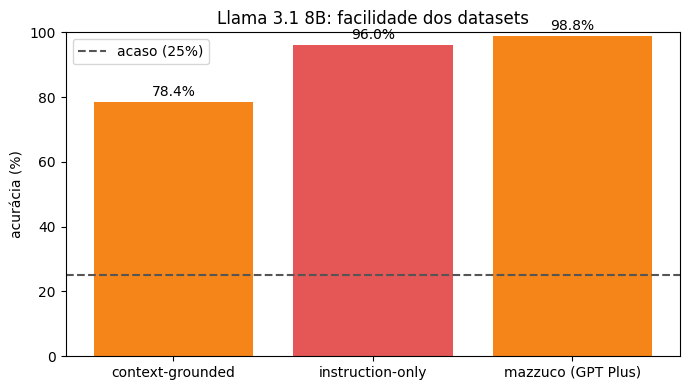

In [8]:
llama_summary = summarize(llama_results, "Llama 3.1 8B")
display(llama_summary)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(llama_summary["dataset"], llama_summary["accuracy_pct"], color=["#f58518", "#e45756"])
ax.axhline(25, color="#555555", linestyle="--", label="acaso (25%)")
ax.set_ylim(0, 100)
ax.set_ylabel("acurácia (%)")
ax.set_title("Llama 3.1 8B: facilidade dos datasets")
for bar, value in zip(bars, llama_summary["accuracy_pct"]):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 2, f"{value:.1f}%", ha="center")
ax.legend()
plt.tight_layout(); plt.show()

## 3. Comparação conjunta

A conclusão deve considerar a média dos modelos e também a diferença entre eles. Um dataset consistentemente mais fácil tende a ficar acima do outro nos dois modelos.

model,Llama 3.1 8B,Phi-4 mini
dataset,,
context-grounded,78.4,78.4
instruction-only,96.0,88.0
mazzuco (GPT Plus),98.8,98.8


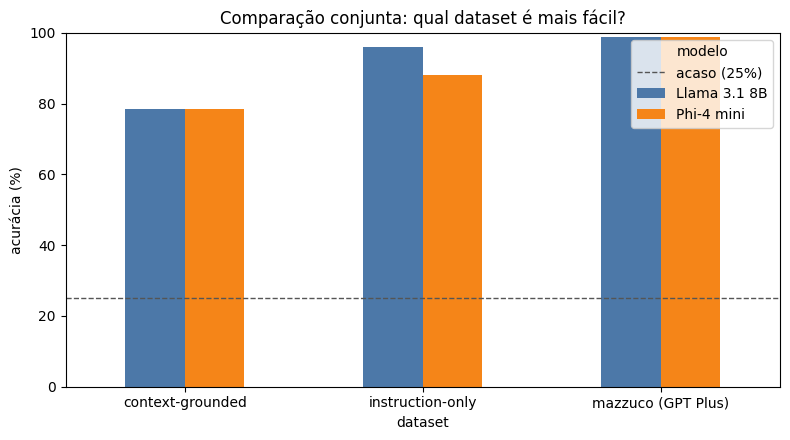

,dataset,accuracy_media,accuracy_min,accuracy_max
2,mazzuco (GPT Plus),98.8,98.8,98.8
1,instruction-only,92.0,88.0,96.0
0,context-grounded,78.4,78.4,78.4


In [9]:
combined = pd.concat([phi_summary, llama_summary], ignore_index=True)
display(combined.pivot(index="dataset", columns="model", values="accuracy_pct").round(1))

plot_data = combined.pivot(index="dataset", columns="model", values="accuracy_pct")
ax = plot_data.plot(kind="bar", figsize=(8, 4.5), color=["#4c78a8", "#f58518"])
ax.axhline(25, color="#555555", linestyle="--", linewidth=1, label="acaso (25%)")
ax.set_ylim(0, 100)
ax.set_ylabel("acurácia (%)")
ax.set_xlabel("dataset")
ax.set_title("Comparação conjunta: qual dataset é mais fácil?")
ax.legend(title="modelo")
plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

final_summary = combined.groupby("dataset", as_index=False).agg(
    accuracy_media=("accuracy_pct", "mean"),
    accuracy_min=("accuracy_pct", "min"),
    accuracy_max=("accuracy_pct", "max"),
)
final_summary.sort_values("accuracy_media", ascending=False).round(1)